<a href="https://colab.research.google.com/github/aryaganu10-cpu/GenAi/blob/main/genai_task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving floorplans_v2-20251223T170650Z-3-001.zip to floorplans_v2-20251223T170650Z-3-001.zip


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
from PIL import Image
import glob

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. GAN Hyperparameters
HPARAMS = {
    "img_size": 256,         # Floorplans require decent resolution
    "channels": 1,           # Grayscale
    "batch_size": 32,
    "lr": 0.0002,            # Standard DCGAN learning rate
    "b1": 0.5,               # Adam: decay of first order momentum of gradient
    "b2": 0.999,             # Adam: decay of second order momentum of gradient
    "latent_dim": 100,       # Dimensionality of the latent space (noise vector)
    "epochs": 100            # GANs often need more epochs than Flow Matching
}

# 3. Data Extraction
# Ensure the zip file is uploaded to Colab before running this
zip_path = '/content/floorplans_v2-20251223T170650Z-3-001.zip'
if os.path.exists(zip_path):
    print("Found zip file. Extracting...")
    !unzip -q {zip_path} -d floorplan_data
    print("Dataset extracted to 'floorplan_data'.")
else:
    print(f"⚠️ Warning: {zip_path} not found. Please upload it.")

# 4. Dataset Class (Reused/Adapted)
class FloorplanDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, size=(256, 256), transform=None):
        self.root_dir = root_dir
        self.image_paths = []
        for ext in ['jpg', 'jpeg', 'png']:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, '**', f'*.{ext}'), recursive=True))
        self.transform = transform # Store transform as an instance variable

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert('L')
        except:
            img = Image.new('L', (HPARAMS["img_size"], HPARAMS["img_size"])) # Placeholder for corrupted image

        if self.transform: # Access transform via self
            img = self.transform(img)
        return img

Using device: cuda
Found zip file. Extracting...
Dataset extracted to 'floorplan_data'.


In [ ]:
# --- Weights Initialization (Crucial for DCGAN stability) ---
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

# --- Generator ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.init_size = HPARAMS["img_size"] // 16 # Starting feature map size

        # Initial dense layer to map latent space to feature maps
        self.l1 = nn.Sequential(
            nn.Linear(HPARAMS["latent_dim"], 128 * self.init_size ** 2)
        )

        # Upsampling blocks
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32, 0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, HPARAMS["channels"], 3, stride=1, padding=1),
            nn.Tanh() # Output range [-1, 1]
        )

    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# --- Discriminator ---
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [nn.Conv2d(in_filters, out_filters, 3, 2, 1),
                     nn.LeakyReLU(0.2, inplace=True),
                     nn.Dropout2d(0.25)]
            if bn:
                block.append(nn.BatchNorm2d(out_filters, 0.8))
            return block

        self.model = nn.Sequential(
            *discriminator_block(HPARAMS["channels"], 16, bn=False),
            *discriminator_block(16, 32),
            *discriminator_block(32, 64),
            *discriminator_block(64, 128),
        )

        # The height and width of downsampled image
        ds_size = HPARAMS["img_size"] // 2**4
        self.adv_layer = nn.Sequential(nn.Linear(128 * ds_size ** 2, 1), nn.Sigmoid())

    def forward(self, img):
        out = self.model(img)
        out = out.view(out.shape[0], -1)
        validity = self.adv_layer(out)
        return validity

In [ ]:
def train_gan_model():
    # 1. Prepare Data
    dataset = FloorplanDataset(
        root_dir='floorplan_data',
        size=(HPARAMS["img_size"], HPARAMS["img_size"]),
        transform=transforms.Compose([
            transforms.Resize((HPARAMS["img_size"], HPARAMS["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]) # Normalize to [-1, 1]
        ])
    )
    dataloader = DataLoader(dataset, batch_size=HPARAMS["batch_size"], shuffle=True, drop_last=True)

    # 2. Initialize Models and Optimizers
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)

    # Initialize weights
    generator.apply(weights_init_normal)
    discriminator.apply(weights_init_normal)

    # Binary Cross Entropy Loss
    adversarial_loss = torch.nn.BCELoss().to(device)

    optimizer_G = torch.optim.Adam(generator.parameters(), lr=HPARAMS["lr"], betas=(HPARAMS["b1"], HPARAMS["b2"]))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=HPARAMS["lr"], betas=(HPARAMS["b1"], HPARAMS["b2"]))

    print(f"🏗️ Starting GAN training for {HPARAMS['epochs']} epochs...")

    # 3. Training Loop
    for epoch in range(HPARAMS['epochs']):
        pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")

        for i, imgs in pbar:
            imgs = imgs.to(device)

            # Ground truths
            valid = torch.ones(imgs.size(0), 1, requires_grad=False).to(device)
            fake = torch.zeros(imgs.size(0), 1, requires_grad=False).to(device)

            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad()
            z = torch.randn(imgs.size(0), HPARAMS["latent_dim"]).to(device) # Sample noise
            gen_imgs = generator(z)
            g_loss = adversarial_loss(discriminator(gen_imgs), valid) # Generator wants D to think imgs are valid
            g_loss.backward()
            optimizer_G.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(imgs), valid)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            pbar.set_postfix({'D Loss': d_loss.item(), 'G Loss': g_loss.item()})

    return generator

In [ ]:
# Re-run this cell to update the class definition
class FloorplanDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, size=(256, 256), transform=None):
        self.root_dir = root_dir
        self.image_paths = []
        for ext in ['jpg', 'jpeg', 'png']:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, '**', f'*.{ext}'), recursive=True))
        self.transform = transform # Store transform as an instance variable

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert('L')
        except:
            # Return a blank black image if the file is corrupt
            img = Image.new('L', (HPARAMS["img_size"], HPARAMS["img_size"])) # Placeholder for corrupted image

        # --- FIX IS HERE ---
        if self.transform:
            img = self.transform(img)
        # -------------------

        return img

🏗️ Starting GAN training for 100 epochs...


Epoch 99: 100%|██████████| 31/31 [00:04<00:00,  6.85it/s, D Loss=0.624, G Loss=1.18]


 Generator saved to floorplan_gan_generator.pth

 Generating Synthetic Floorplans from Noise...


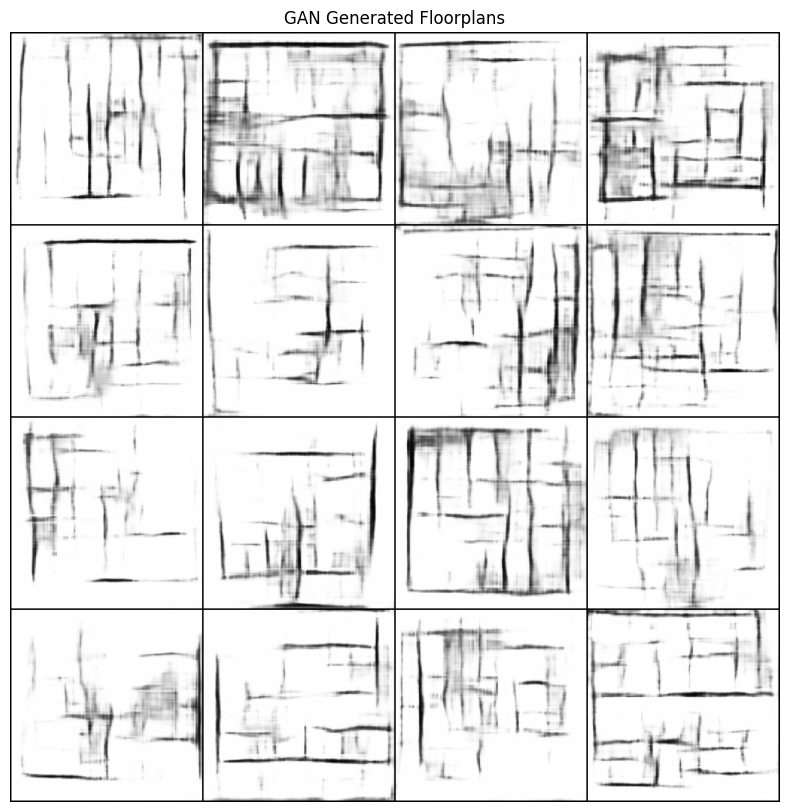

In [ ]:
def generate_gan_grid(generator, n_samples=16):
    generator.eval()
    print("\n Generating Synthetic Floorplans from Noise...")

    # Sample random noise
    z = torch.randn(n_samples, HPARAMS["latent_dim"]).to(device)

    with torch.no_grad():
        gen_imgs = generator(z)

    # Denormalize: [-1, 1] -> [0, 1]
    gen_imgs = (gen_imgs * 0.5) + 0.5

    grid = make_grid(gen_imgs, nrow=4, padding=2)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title("GAN Generated Floorplans")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    # 1. Train
    if os.path.exists('floorplan_data'):
        trained_generator = train_gan_model()

        # 2. Save
        torch.save(trained_generator.state_dict(), "floorplan_gan_generator.pth")
        print(" Generator saved to floorplan_gan_generator.pth")

        # 3. Generate
        generate_gan_grid(trained_generator)
    else:
        print(" Data not found. Skipping training.")